# Commodity-Linked Stocks vs. the S&P 500: Did Market Exposure Change After 2020?

**Research question:** How do commodity-producing equities behave relative to the broad U.S. equity market, and did that relationship change after 2020?

**Universe:** Oil/Energy (XOM, COP), Metals/Mining (FCX, NEM), Agriculture (ADM)
**Market proxy:** SPY  **Commodity proxies:** USO (oil), CPER (copper), GLD (gold), DBA (agriculture)
**Risk-free rate:** 13-week U.S. T-bill yield (`^IRX`), daily

**Methods**
1. Return, volatility, Sharpe ratio, and correlation for 2016–2020 vs. 2021–2025
2. CAPM regressions with Newey–West (HAC) standard errors
3. A pooled regression that tests whether each stock's beta changed after 2020
4. Rolling 252-day beta
5. A two-factor model (market + the stock's own commodity)
6. A robustness check that drops 2020

**Reproducibility:** prices are downloaded once and frozen in `data/prices.csv`. Every number in this notebook is computed from that file; figures are saved to `figures/`.

## 0. Setup

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

TICKERS = ["XOM", "COP", "FCX", "NEM", "ADM"]
BENCHMARK = "SPY"
RF_TICKER = "^IRX"   # 13-week T-bill yield, annualized, in percent

# Each stock is paired with an ETF that tracks its main commodity
COMMODITY_PROXY = {"XOM": "USO", "COP": "USO", "FCX": "CPER", "NEM": "GLD", "ADM": "DBA"}
COMMODITIES = sorted(set(COMMODITY_PROXY.values()))

START, END = "2016-01-01", "2026-01-01"          # yfinance END is exclusive
PERIODS = {
    "2016–2020": ("2016-01-01", "2020-12-31"),
    "2021–2025": ("2021-01-01", "2025-12-31"),
}
SPLIT_DATE = "2021-01-01"
ROBUSTNESS_PERIOD = ("2016–2019", ("2016-01-01", "2019-12-31"))

HAC_LAGS = 5          # Newey–West lags (one trading week)
ROLL_WINDOW = 252     # one trading year

DATA_PATH = Path("data/prices.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## 1. Data

Prices are adjusted for splits and dividends. Yahoo Finance re-adjusts history whenever a new dividend is paid, so re-downloading later can shift results slightly. To keep every number reproducible, the data is saved to `data/prices.csv` on the first run and loaded from that file afterwards (set `refresh=True` to re-download).

`^IRX` is quoted as an annualized percentage, so the daily risk-free rate is

$$
r_{f,t} = \frac{\text{IRX}_t}{100 \times 252}
$$

In [4]:
def load_prices(path=DATA_PATH, refresh=False):
    """Load frozen prices from CSV; download from Yahoo Finance only if the file is missing."""
    if path.exists() and not refresh:
        return pd.read_csv(path, index_col=0, parse_dates=True)

    import yfinance as yf
    symbols = TICKERS + [BENCHMARK] + COMMODITIES + [RF_TICKER]
    raw = yf.download(symbols, start=START, end=END, auto_adjust=True, progress=False)["Close"]
    raw = raw[symbols]
    path.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(path)
    print(f"Downloaded and saved to {path}")
    return raw


prices_all = load_prices()

ASSETS = TICKERS + [BENCHMARK] + COMMODITIES
prices = prices_all[ASSETS].dropna()
returns = prices.pct_change().dropna()

# Daily risk-free rate, aligned to trading days
rf = (prices_all[RF_TICKER] / 100 / 252).ffill().reindex(returns.index).ffill().bfill()
excess = returns.sub(rf, axis=0)


def window(df, period):
    start, end = period
    return df.loc[start:end]


print(f"{len(returns):,} daily returns from {returns.index.min().date()} to {returns.index.max().date()}")
for name, period in PERIODS.items():
    print(f"  {name}: {len(window(returns, period)):,} days, "
          f"average risk-free rate {window(rf, period).mean() * 252 * 100:.2f}%")

2,513 daily returns from 2016-01-05 to 2025-12-31
  2016–2020: 1,258 days, average risk-free rate 1.10%
  2021–2025: 1,255 days, average risk-free rate 3.21%


## 2. Return, Risk, and Sharpe Ratio

$$
\text{Sharpe} = \frac{\overline{r - r_f}}{\sigma(r - r_f)} \times \sqrt{252}
$$

Using the actual T-bill rate matters: rates were near zero for much of 2016–2021 and above 5% in 2023–2024, so a constant rate would distort the comparison between periods.

In [5]:
def period_stats(r, x):
    cols = TICKERS + [BENCHMARK]
    r, x = r[cols], x[cols]
    return pd.DataFrame({
        "ann_arith_return_%": r.mean() * 252 * 100,
        "ann_geom_return_%": ((1 + r).prod() ** (252 / len(r)) - 1) * 100,
        "ann_volatility_%": r.std() * np.sqrt(252) * 100,
        "sharpe": x.mean() / x.std() * np.sqrt(252),
        "corr_with_SPY": r.corrwith(r[BENCHMARK]),
    })


stats = {name: period_stats(window(returns, p), window(excess, p)) for name, p in PERIODS.items()}

for name, df in stats.items():
    print(name)
    display(df)

2016–2020


,ann_arith_return_%,ann_geom_return_%,ann_volatility_%,sharpe,corr_with_SPY
XOM,-3.7986,-7.5991,28.6553,-0.1711,0.6812
COP,8.6838,-0.6418,43.1124,0.1758,0.6192
FCX,45.1843,32.6563,58.2449,0.7568,0.5613
NEM,31.6614,28.7770,35.7000,0.8559,0.1566
ADM,13.5726,10.5363,26.6093,0.4685,0.6731
SPY,16.1589,15.4480,18.8612,0.7981,1.0000


2021–2025


,ann_arith_return_%,ann_geom_return_%,ann_volatility_%,sharpe,corr_with_SPY
XOM,29.2272,29.1289,27.0138,0.9627,0.3419
COP,26.3057,22.9897,33.4492,0.6902,0.3862
FCX,25.0946,15.9047,45.4611,0.4813,0.5532
NEM,19.7692,14.3778,35.5224,0.4661,0.2361
ADM,9.4081,5.5871,27.7205,0.2234,0.3223
SPY,14.9139,14.3961,17.1160,0.6837,1.0000


## 3. CAPM Regressions (HAC Standard Errors)

For each stock and period:

$$
r_{i,t} - r_{f,t} = \alpha_i + \beta_i \,(r_{m,t} - r_{f,t}) + \varepsilon_{i,t}
$$

Daily returns have fat tails and volatility that clusters in time, which makes ordinary OLS standard errors too small. Newey–West (HAC) standard errors correct for both, so the p-values below use HAC. The plain OLS p-value for alpha is shown for comparison.

In [6]:
def fit_hac(y, X):
    """OLS with Newey–West (HAC) standard errors."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})


def capm_table(x):
    rows = []
    for t in TICKERS:
        m = fit_hac(x[t], x[BENCHMARK])
        m_ols = sm.OLS(x[t], sm.add_constant(x[BENCHMARK])).fit()
        rows.append({
            "ticker": t,
            "beta": m.params[BENCHMARK],
            "beta_se": m.bse[BENCHMARK],
            "alpha_ann_%": m.params["const"] * 252 * 100,
            "alpha_p_hac": m.pvalues["const"],
            "alpha_p_ols": m_ols.pvalues["const"],
            "r_squared": m.rsquared,
            "n_obs": int(m.nobs),
        })
    return pd.DataFrame(rows).set_index("ticker")


capm = {name: capm_table(window(excess, p)) for name, p in PERIODS.items()}

for name, df in capm.items():
    print(name)
    display(df)

2016–2020


,beta,beta_se,alpha_ann_%,alpha_p_hac,alpha_p_ols,r_squared,n_obs
ticker,,,,,,,
XOM,1.0349,0.0555,-20.4827,0.0146,0.0296,0.4640,1258
COP,1.4154,0.0864,-13.7289,0.3379,0.3658,0.3835,1258
FCX,1.7338,0.1191,17.9784,0.3738,0.4056,0.3152,1258
NEM,0.2966,0.1046,26.0925,0.0786,0.0991,0.0246,1258
ADM,0.9498,0.0420,-1.8298,0.8308,0.8357,0.4532,1258


2021–2025


,beta,beta_se,alpha_ann_%,alpha_p_hac,alpha_p_ols,r_squared,n_obs
ticker,,,,,,,
XOM,0.5403,0.0569,19.6927,0.0968,0.0841,0.1171,1255
COP,0.7558,0.0852,14.2489,0.3351,0.3036,0.1495,1255
FCX,1.4698,0.0614,4.6836,0.7833,0.7829,0.3061,1255
NEM,0.4899,0.0734,10.8241,0.4971,0.4848,0.0557,1255
ADM,0.5226,0.0486,0.0797,0.9946,0.9946,0.1041,1255


## 4. Did Beta Actually Change? (Pooled Test)

Comparing two separate betas does not tell us whether the difference is statistically significant. Pooling both periods with a post-2020 dummy $D_t$ does:

$$
r_{i,t} - r_{f,t} = \alpha + \beta\,(r_{m,t} - r_{f,t}) + \gamma\, D_t + \delta\, D_t\,(r_{m,t} - r_{f,t}) + \varepsilon_t
$$

- $\delta$ = change in beta after 2020. A significant $\delta$ means market exposure really shifted.
- $\gamma$ = change in daily alpha after 2020 (shown annualized).

In [7]:
FULL_SAMPLE = (PERIODS["2016–2020"][0], PERIODS["2021–2025"][1])


def post_dummy(index, split=SPLIT_DATE):
    return pd.Series((index >= pd.Timestamp(split)).astype(float), index=index, name="post")


def beta_change_test(x):
    post = post_dummy(x.index)
    mkt = x[BENCHMARK]
    X = pd.DataFrame({"mkt": mkt, "post": post, "mkt_x_post": mkt * post})
    rows = []
    for t in TICKERS:
        m = fit_hac(x[t], X)
        rows.append({
            "ticker": t,
            "beta_before": m.params["mkt"],
            "beta_after": m.params["mkt"] + m.params["mkt_x_post"],
            "beta_change": m.params["mkt_x_post"],
            "beta_change_p": m.pvalues["mkt_x_post"],
            "alpha_change_ann_%": m.params["post"] * 252 * 100,
            "alpha_change_p": m.pvalues["post"],
        })
    return pd.DataFrame(rows).set_index("ticker")


beta_change = beta_change_test(window(excess, FULL_SAMPLE))
display(beta_change)

,beta_before,beta_after,beta_change,beta_change_p,alpha_change_ann_%,alpha_change_p
ticker,,,,,,
XOM,1.0349,0.5403,-0.4946,0.0000,40.1754,0.0057
COP,1.4154,0.7558,-0.6596,0.0000,27.9778,0.1740
FCX,1.7338,1.4698,-0.2640,0.0487,-13.2948,0.6145
NEM,0.2966,0.4899,0.1933,0.1303,-15.2683,0.4833
ADM,0.9498,0.5226,-0.4271,0.0000,1.9095,0.8952


## 5. Rolling 252-Day Beta

Two fixed windows show *that* beta changed; a rolling window shows *when*.

$$
\beta_t = \frac{\operatorname{Cov}_{252}(r_i - r_f,\; r_m - r_f)}{\operatorname{Var}_{252}(r_m - r_f)}
$$

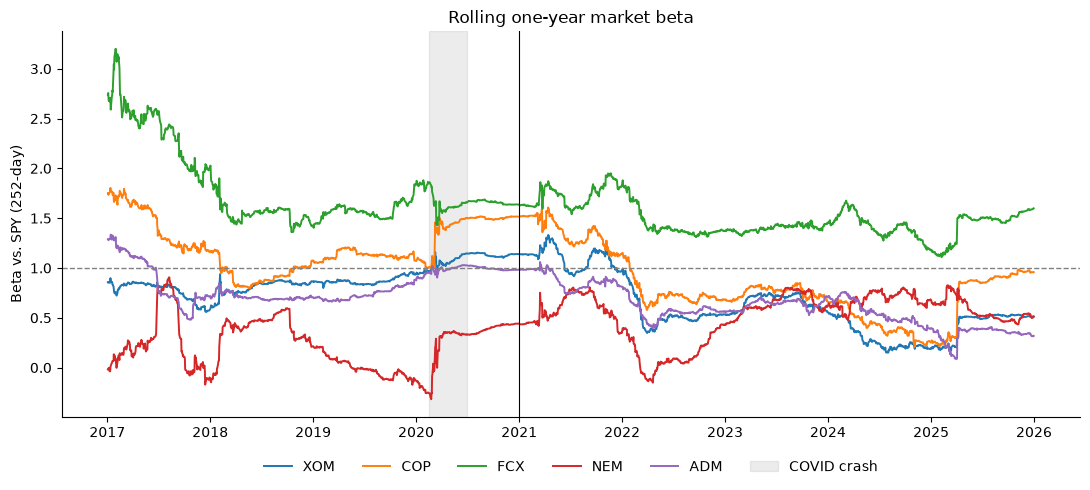

Rolling beta at the end of each year:


,XOM,COP,FCX,NEM,ADM
Date,,,,,
2017,0.5700,1.1600,2.0000,-0.1000,0.7100
2018,0.8600,1.0700,1.4200,0.2100,0.7100
2019,0.9400,1.0700,1.8400,-0.1300,0.8800
2020,1.1400,1.5200,1.6400,0.4400,0.9800
2021,0.9700,1.1400,1.8300,0.3500,0.8100
2022,0.5300,0.6800,1.3700,0.4300,0.5600
2023,0.5600,0.6700,1.4400,0.6100,0.7000
2024,0.1900,0.2500,1.1800,0.6800,0.3900
2025,0.5200,0.9600,1.6000,0.5100,0.3200


In [8]:
mkt_x = excess[BENCHMARK]
rolling_beta = pd.DataFrame({
    t: excess[t].rolling(ROLL_WINDOW).cov(mkt_x) / mkt_x.rolling(ROLL_WINDOW).var()
    for t in TICKERS
}).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
for t in TICKERS:
    ax.plot(rolling_beta.index, rolling_beta[t], lw=1.4, label=t)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-06-30"), color="gray", alpha=0.15,
           label="COVID crash")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="black", lw=0.8)
ax.set_ylabel("Beta vs. SPY (252-day)")
ax.set_title("Rolling one-year market beta")
ax.legend(frameon=False, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIG_DIR / "rolling_beta.png", dpi=150, bbox_inches="tight")
plt.show()

print("Rolling beta at the end of each year:")
display(rolling_beta.groupby(rolling_beta.index.year).last().round(2))

## 6. Two-Factor Model: Market + Commodity

CAPM puts everything that is not the market into alpha and the residual. Adding each stock's own commodity separates the two exposures:

$$
r_{i,t} - r_{f,t} = \alpha_i + \beta_{m}\,(r_{m,t} - r_{f,t}) + \beta_{c}\,(r_{c,t} - r_{f,t}) + \varepsilon_{i,t}
$$

If commodity-specific drivers became more important after 2020, we should see $\beta_c$ and the R² gain from adding the commodity both rise in 2021–2025.

In [9]:
def two_factor_table(x):
    rows = []
    for t in TICKERS:
        c = COMMODITY_PROXY[t]
        m1 = fit_hac(x[t], x[BENCHMARK])
        m2 = fit_hac(x[t], x[[BENCHMARK, c]])
        rows.append({
            "ticker": t,
            "commodity": c,
            "beta_mkt": m2.params[BENCHMARK],
            "beta_cmdty": m2.params[c],
            "beta_cmdty_p": m2.pvalues[c],
            "alpha_ann_%": m2.params["const"] * 252 * 100,
            "alpha_p": m2.pvalues["const"],
            "r2_capm": m1.rsquared,
            "r2_two_factor": m2.rsquared,
            "r2_gain": m2.rsquared - m1.rsquared,
        })
    return pd.DataFrame(rows).set_index("ticker")


def commodity_beta_change_test(x):
    post = post_dummy(x.index)
    rows = []
    for t in TICKERS:
        c = COMMODITY_PROXY[t]
        X = pd.DataFrame({
            "mkt": x[BENCHMARK], "cmdty": x[c], "post": post,
            "mkt_x_post": x[BENCHMARK] * post, "cmdty_x_post": x[c] * post,
        })
        m = fit_hac(x[t], X)
        rows.append({
            "ticker": t,
            "mkt_beta_change": m.params["mkt_x_post"],
            "mkt_beta_change_p": m.pvalues["mkt_x_post"],
            "cmdty_beta_change": m.params["cmdty_x_post"],
            "cmdty_beta_change_p": m.pvalues["cmdty_x_post"],
        })
    return pd.DataFrame(rows).set_index("ticker")


two_factor = {name: two_factor_table(window(excess, p)) for name, p in PERIODS.items()}
for name, df in two_factor.items():
    print(name)
    display(df)

print("Change after 2020 (pooled two-factor model, HAC p-values)")
cmdty_change = commodity_beta_change_test(window(excess, FULL_SAMPLE))
display(cmdty_change)

2016–2020


,commodity,beta_mkt,beta_cmdty,beta_cmdty_p,alpha_ann_%,alpha_p,r2_capm,r2_two_factor,r2_gain
ticker,,,,,,,,,
XOM,USO,0.8689,0.1866,0.0000,-15.9000,0.0470,0.4640,0.5306,0.0665
COP,USO,1.0337,0.4293,0.0000,-3.1881,0.8031,0.3835,0.5390,0.1555
FCX,CPER,1.3203,1.0177,0.0000,13.9196,0.4208,0.3152,0.4319,0.1166
NEM,GLD,0.3219,1.7090,0.0000,7.1061,0.5090,0.0246,0.4684,0.4439
ADM,DBA,0.9499,-0.0006,0.9923,-1.8339,0.8301,0.4532,0.4532,0.0000


2021–2025


,commodity,beta_mkt,beta_cmdty,beta_cmdty_p,alpha_ann_%,alpha_p,r2_capm,r2_two_factor,r2_gain
ticker,,,,,,,,,
XOM,USO,0.3644,0.4873,0.0000,13.3792,0.1209,0.1171,0.4627,0.3456
COP,USO,0.5406,0.5964,0.0000,6.5213,0.5461,0.1495,0.4872,0.3378
FCX,CPER,0.9690,0.9283,0.0000,1.3634,0.9150,0.3061,0.5626,0.2565
NEM,GLD,0.3283,1.4458,0.0000,-7.5939,0.5074,0.0557,0.4545,0.3988
ADM,DBA,0.4857,0.2588,0.0000,-1.9563,0.8637,0.1041,0.1216,0.0176


Change after 2020 (pooled two-factor model, HAC p-values)


,mkt_beta_change,mkt_beta_change_p,cmdty_beta_change,cmdty_beta_change_p
ticker,,,,
XOM,-0.5045,0.0000,0.3006,0.0000
COP,-0.4931,0.0000,0.1671,0.0147
FCX,-0.3514,0.0037,-0.0893,0.6420
NEM,0.0064,0.9516,-0.2632,0.0041
ADM,-0.4642,0.0000,0.2594,0.0014


## 7. Robustness Check: Excluding 2020

The COVID crash in 2020 produced extreme market-wide moves that can inflate betas and R². Re-estimating the first period on 2016–2019 checks whether the post-2020 change is structural or just a 2020 effect.

In [10]:
rob_name, rob_period = ROBUSTNESS_PERIOD
capm_rob = capm_table(window(excess, rob_period))
p1, p2 = PERIODS

robustness = pd.DataFrame({
    f"beta {p1}": capm[p1]["beta"],
    f"beta {rob_name}": capm_rob["beta"],
    f"beta {p2}": capm[p2]["beta"],
    f"R² {p1}": capm[p1]["r_squared"],
    f"R² {rob_name}": capm_rob["r_squared"],
    f"R² {p2}": capm[p2]["r_squared"],
})
display(robustness)

still_fell = [t for t in TICKERS if capm[p2].loc[t, "beta"] < capm_rob.loc[t, "beta"]]
print(f"Beta is lower in {p2} than in {rob_name} for {len(still_fell)} of {len(TICKERS)} names: {still_fell}")

,beta 2016–2020,beta 2016–2019,beta 2021–2025,R² 2016–2020,R² 2016–2019,R² 2021–2025
ticker,,,,,,
XOM,1.0349,0.8596,0.5403,0.4640,0.3744,0.1171
COP,1.4154,1.2480,0.7558,0.3835,0.2559,0.1495
FCX,1.7338,1.8974,1.4698,0.3152,0.2016,0.3061
NEM,0.2966,0.0508,0.4899,0.0246,0.0004,0.0557
ADM,0.9498,0.8951,0.5226,0.4532,0.2733,0.1041


Beta is lower in 2021–2025 than in 2016–2019 for 4 of 5 names: ['XOM', 'COP', 'FCX', 'ADM']


## 8. Summary Tables

In [11]:
summary = {}
for name in PERIODS:
    summary[name] = pd.concat([
        stats[name][["ann_geom_return_%", "ann_volatility_%", "sharpe", "corr_with_SPY"]],
        capm[name][["beta", "alpha_ann_%", "alpha_p_hac", "r_squared"]],
        two_factor[name][["beta_cmdty", "r2_two_factor"]],
    ], axis=1)
    print(name)
    display(summary[name])

Path("results").mkdir(exist_ok=True)
pd.concat(summary, names=["period", "ticker"]).to_csv("results/summary.csv")
beta_change.to_csv("results/beta_change_test.csv")
cmdty_change.to_csv("results/commodity_beta_change_test.csv")

2016–2020


,ann_geom_return_%,ann_volatility_%,sharpe,corr_with_SPY,beta,alpha_ann_%,alpha_p_hac,r_squared,beta_cmdty,r2_two_factor
XOM,-7.5991,28.6553,-0.1711,0.6812,1.0349,-20.4827,0.0146,0.4640,0.1866,0.5306
COP,-0.6418,43.1124,0.1758,0.6192,1.4154,-13.7289,0.3379,0.3835,0.4293,0.5390
FCX,32.6563,58.2449,0.7568,0.5613,1.7338,17.9784,0.3738,0.3152,1.0177,0.4319
NEM,28.7770,35.7000,0.8559,0.1566,0.2966,26.0925,0.0786,0.0246,1.7090,0.4684
ADM,10.5363,26.6093,0.4685,0.6731,0.9498,-1.8298,0.8308,0.4532,-0.0006,0.4532
SPY,15.4480,18.8612,0.7981,1.0000,NaN,NaN,NaN,NaN,NaN,NaN


2021–2025


,ann_geom_return_%,ann_volatility_%,sharpe,corr_with_SPY,beta,alpha_ann_%,alpha_p_hac,r_squared,beta_cmdty,r2_two_factor
XOM,29.1289,27.0138,0.9627,0.3419,0.5403,19.6927,0.0968,0.1171,0.4873,0.4627
COP,22.9897,33.4492,0.6902,0.3862,0.7558,14.2489,0.3351,0.1495,0.5964,0.4872
FCX,15.9047,45.4611,0.4813,0.5532,1.4698,4.6836,0.7833,0.3061,0.9283,0.5626
NEM,14.3778,35.5224,0.4661,0.2361,0.4899,10.8241,0.4971,0.0557,1.4458,0.4545
ADM,5.5871,27.7205,0.2234,0.3223,0.5226,0.0797,0.9946,0.1041,0.2588,0.1216
SPY,14.3961,17.1160,0.6837,1.0000,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Visualizations

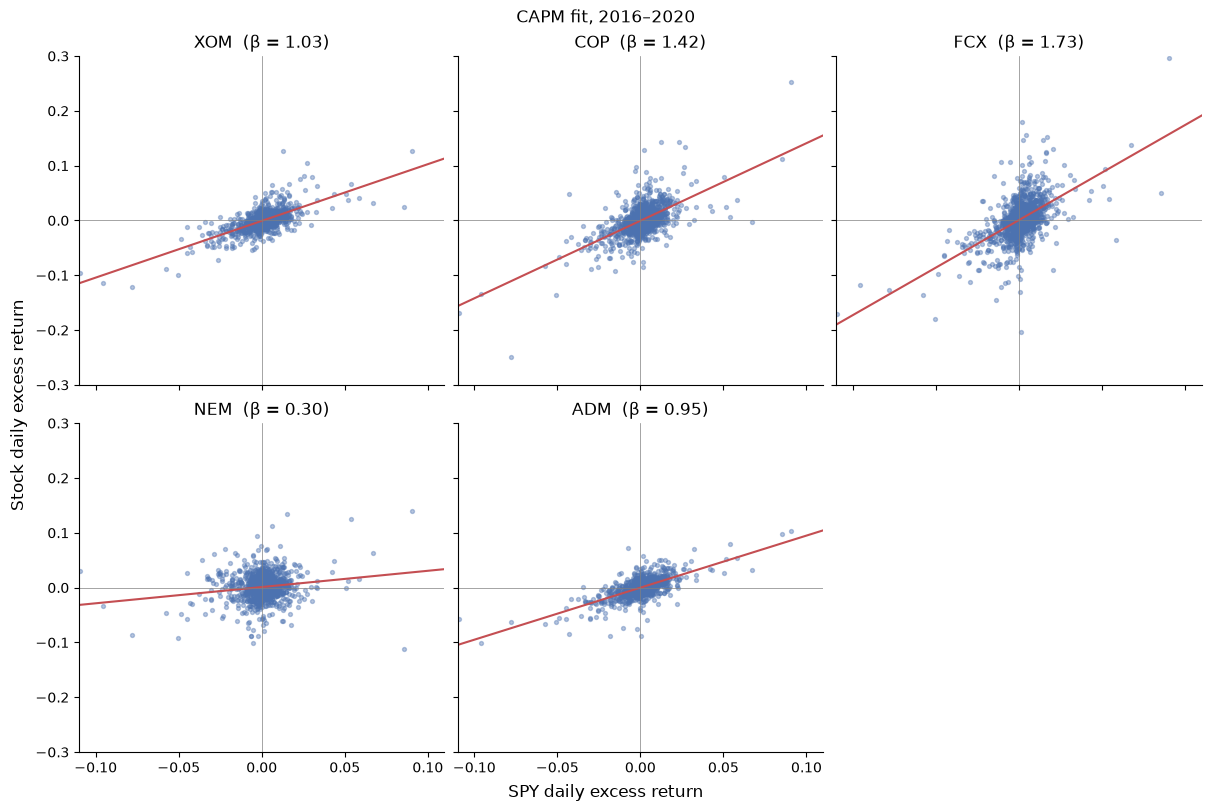

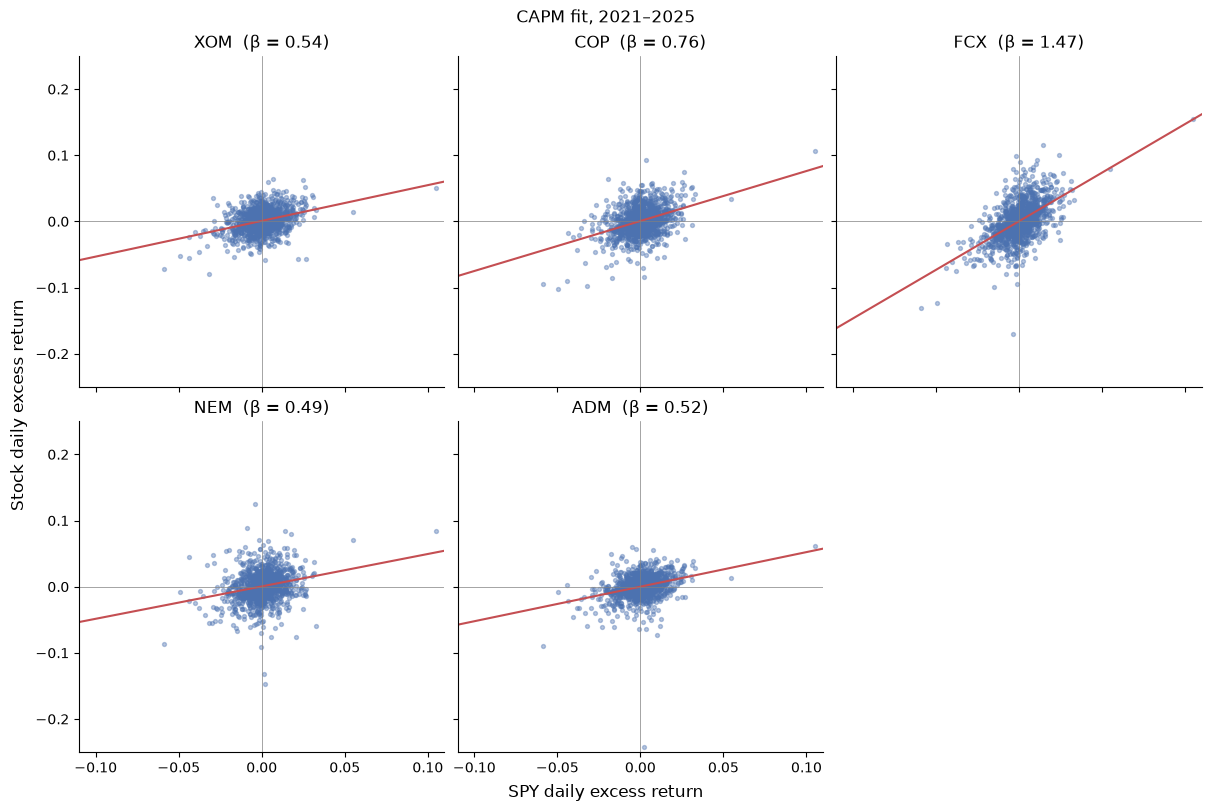

In [12]:
def scatter_grid(x, capm_df, title, fname):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True,
                             constrained_layout=True)
    axes = axes.flatten()
    # Separate x and y limits; both still include every point
    xlim = float(np.ceil(x[BENCHMARK].abs().max() * 100) / 100)
    ylim = float(np.ceil(x[TICKERS].abs().max().max() * 100) / 100)
    grid = np.linspace(-xlim, xlim, 100)

    for ax, t in zip(axes, TICKERS):
        beta = capm_df.loc[t, "beta"]
        alpha_daily = capm_df.loc[t, "alpha_ann_%"] / 100 / 252
        ax.scatter(x[BENCHMARK], x[t], s=8, alpha=0.4, color="#4C72B0")
        ax.plot(grid, alpha_daily + beta * grid, color="#C44E52", lw=1.5)
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        ax.set_xlim(-xlim, xlim)
        ax.set_ylim(-ylim, ylim)
        ax.set_title(f"{t}  (β = {beta:.2f})")
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[len(TICKERS):]:
        ax.axis("off")

    fig.supxlabel(f"{BENCHMARK} daily excess return")
    fig.supylabel("Stock daily excess return")
    fig.suptitle(title)
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


for i, (name, p) in enumerate(PERIODS.items(), start=1):
    scatter_grid(window(excess, p), capm[name], f"CAPM fit, {name}", f"capm_scatter_{i}.png")

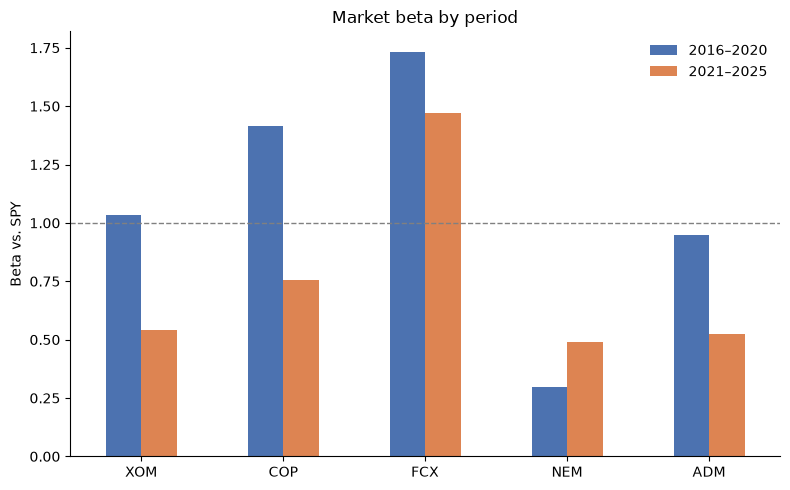

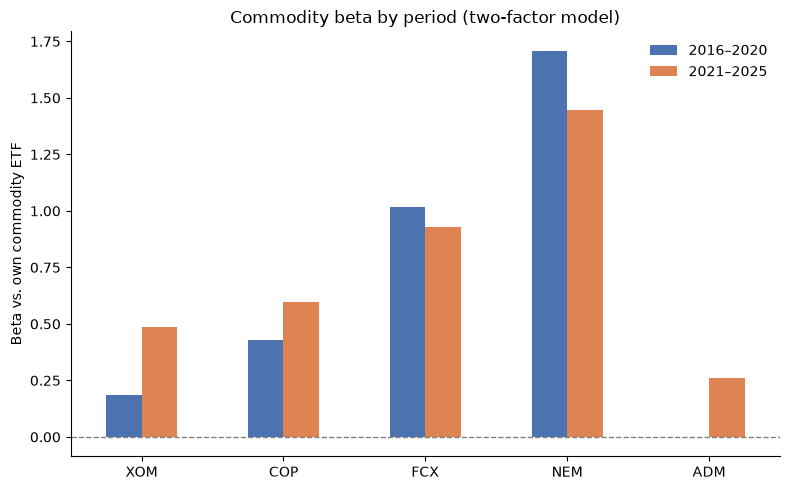

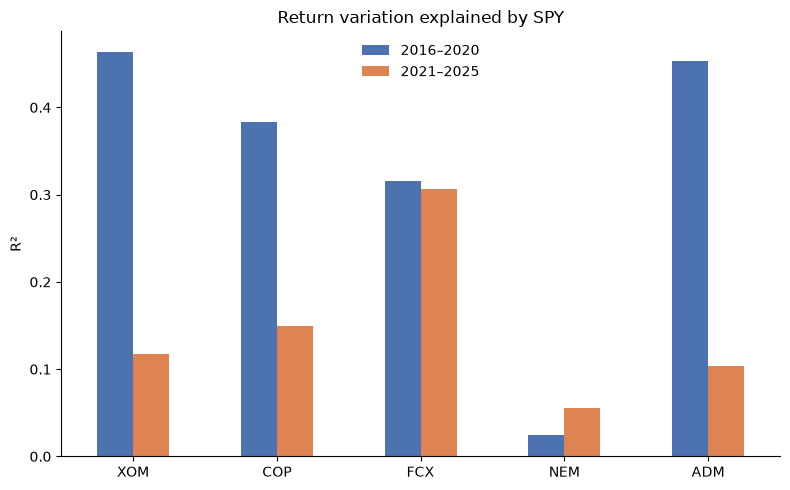

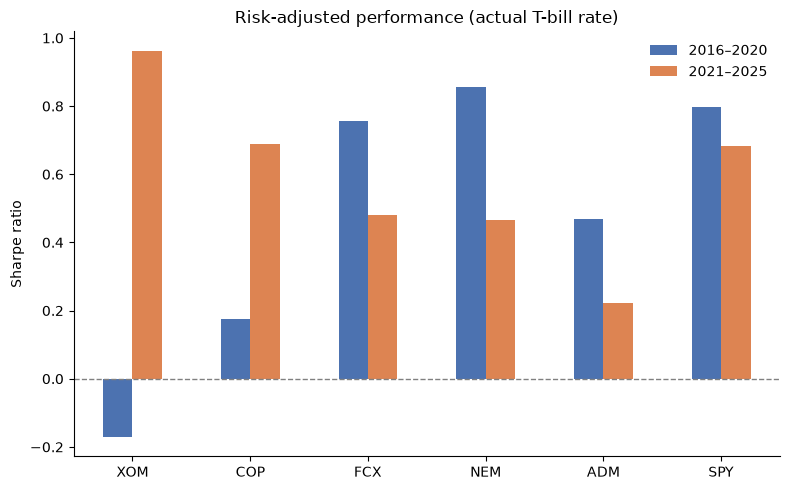

In [13]:
def paired_bars(df, ylabel, title, fname, hline=None):
    ax = df.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"], rot=0)
    if hline is not None:
        ax.axhline(hline, color="gray", ls="--", lw=1)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


paired_bars(pd.DataFrame({n: capm[n]["beta"] for n in PERIODS}),
            "Beta vs. SPY", "Market beta by period", "beta_by_period.png", hline=1.0)

paired_bars(pd.DataFrame({n: two_factor[n]["beta_cmdty"] for n in PERIODS}),
            "Beta vs. own commodity ETF", "Commodity beta by period (two-factor model)",
            "commodity_beta_by_period.png", hline=0.0)

paired_bars(pd.DataFrame({n: capm[n]["r_squared"] for n in PERIODS}),
            "R²", "Return variation explained by SPY", "r2_by_period.png")

paired_bars(pd.DataFrame({n: stats[n]["sharpe"] for n in PERIODS}),
            "Sharpe ratio", "Risk-adjusted performance (actual T-bill rate)",
            "sharpe_by_period.png", hline=0.0)

## 10. Key Results (generated from the tables above)

This cell writes the headline numbers from the analysis, so the findings always match the data.

In [14]:
p1, p2 = PERIODS
c1, c2 = capm[p1], capm[p2]
tf1, tf2 = two_factor[p1], two_factor[p2]
ALPHA = 0.05

fell = [t for t in TICKERS if c2.loc[t, "beta"] < c1.loc[t, "beta"]]
print(f"1. Market beta fell for {len(fell)} of {len(TICKERS)} names: "
      + ", ".join(f"{t} {c1.loc[t, 'beta']:.2f}→{c2.loc[t, 'beta']:.2f}" for t in fell))

sig_change = beta_change.index[beta_change["beta_change_p"] < ALPHA].tolist()
print(f"2. Beta change significant at 5% (HAC, pooled test): {sig_change or 'none'}")

print(f"3. Highest beta: {c1['beta'].idxmax()} in {p1}, {c2['beta'].idxmax()} in {p2}; "
      f"lowest R²: {c1['r_squared'].idxmin()} in {p1}, {c2['r_squared'].idxmin()} in {p2}")

print("4. R² vs SPY: " + ", ".join(
    f"{t} {c1.loc[t, 'r_squared']:.2f}→{c2.loc[t, 'r_squared']:.2f}" for t in TICKERS))

print("5. Commodity beta (two-factor): " + ", ".join(
    f"{t} {tf1.loc[t, 'beta_cmdty']:.2f}→{tf2.loc[t, 'beta_cmdty']:.2f}" for t in TICKERS))
sig_cmdty = cmdty_change.index[cmdty_change["cmdty_beta_change_p"] < ALPHA].tolist()
print(f"   Commodity beta change significant at 5%: {sig_cmdty or 'none'}")
print("   R² gain from adding the commodity: " + ", ".join(
    f"{t} {tf1.loc[t, 'r2_gain']:.2f}→{tf2.loc[t, 'r2_gain']:.2f}" for t in TICKERS))

n_tests = 2 * len(TICKERS)
sig_alpha = [(n, t) for n, df in capm.items() for t in TICKERS if df.loc[t, "alpha_p_hac"] < ALPHA]
print(f"6. Significant CAPM alphas (HAC, 5%): {sig_alpha or 'none'}. "
      f"With {n_tests} tests, about {n_tests * ALPHA:.1f} false positives are expected by chance, "
      f"and P(at least one) = {1 - (1 - ALPHA) ** n_tests:.0%}.")

for name in PERIODS:
    s = stats[name]["sharpe"]
    beat = s[TICKERS][s[TICKERS] > s[BENCHMARK]]
    print(f"7. {name}: SPY Sharpe {s[BENCHMARK]:.2f}; names that beat it: "
          + (", ".join(f"{t} {v:.2f}" for t, v in beat.items()) or "none"))

print(f"8. Robustness ({ROBUSTNESS_PERIOD[0]} vs {p2}): beta still lower for "
      f"{len(still_fell)} of {len(TICKERS)} names")

1. Market beta fell for 4 of 5 names: XOM 1.03→0.54, COP 1.42→0.76, FCX 1.73→1.47, ADM 0.95→0.52
2. Beta change significant at 5% (HAC, pooled test): ['XOM', 'COP', 'FCX', 'ADM']
3. Highest beta: FCX in 2016–2020, FCX in 2021–2025; lowest R²: NEM in 2016–2020, NEM in 2021–2025
4. R² vs SPY: XOM 0.46→0.12, COP 0.38→0.15, FCX 0.32→0.31, NEM 0.02→0.06, ADM 0.45→0.10
5. Commodity beta (two-factor): XOM 0.19→0.49, COP 0.43→0.60, FCX 1.02→0.93, NEM 1.71→1.45, ADM -0.00→0.26
   Commodity beta change significant at 5%: ['XOM', 'COP', 'NEM', 'ADM']
   R² gain from adding the commodity: XOM 0.07→0.35, COP 0.16→0.34, FCX 0.12→0.26, NEM 0.44→0.40, ADM 0.00→0.02
6. Significant CAPM alphas (HAC, 5%): [('2016–2020', 'XOM')]. With 10 tests, about 0.5 false positives are expected by chance, and P(at least one) = 40%.
7. 2016–2020: SPY Sharpe 0.80; names that beat it: NEM 0.86
7. 2021–2025: SPY Sharpe 0.68; names that beat it: XOM 0.96, COP 0.69
8. Robustness (2016–2019 vs 2021–2025): beta still lower f

## 11. Interpretation

**1. Market exposure fell, and the change is real.**
Beta fell for XOM (1.03 → 0.54), COP (1.42 → 0.76), FCX (1.73 → 1.47), and ADM (0.95 → 0.52). The pooled interaction test (Section 4) rejects "no change" at the 5% level for all four. NEM's beta rose (0.30 → 0.50), but that change was not significant. The rolling beta (Section 5) shows when each shift happened.

**When it happened.** The rolling beta shows XOM's and COP's market beta falling sharply in the first half of 2022, from around 1.0–1.2 to about 0.4–0.6. That is when oil rallied after Russia's invasion of Ukraine while equities fell on Fed rate hikes. Neither beta returned to its pre-2020 level. FCX is different: most of its lower average comes from an unusually high beta in 2016–2017 (above 2.5). Since 2018 it has stayed mostly between 1.3 and 1.9, so its "drop" is more about the early sample than about 2020. NEM's rolling beta is the least stable, ranging from about −0.3 in early 2020 to about 0.8, which fits gold's occasional role as a hedge.

**Reading the rolling chart.** A rolling beta jumps when an extreme day enters or leaves the 252-day window. The plateau from March 2020 to March 2021 reflects the COVID crash sitting inside the window, and the jump across names in April 2025 reflects the tariff sell-off entering it. These jumps come from the window itself, not necessarily from a change in the business.

**2. It is not just a COVID effect.**
Dropping 2020 from the first period (Section 7) leaves the conclusion unchanged: beta is still lower after 2020 for 4 of 5 names.

**3. For the oil producers, oil replaced the market.**
In the two-factor model (Section 6), XOM's oil beta rose from 0.19 to 0.49 and COP's from 0.43 to 0.60, both significant. Adding oil raised XOM's R² by 0.35 after 2020, compared with 0.07 before, while SPY's R² for XOM fell from 0.46 to 0.12. In 2016–2020, oil and equities moved together with the growth cycle. In 2021–2022, oil rallied on supply shocks while equities fell on rate hikes, so XOM and COP tracked oil more and the market less.

**4. NEM is a gold stock first.**
SPY explains only 2–6% of NEM's daily variation, while adding GLD raises R² by about 0.40 in both periods. Gold is driven mainly by real interest rates, the dollar, and crisis demand, which are largely separate from what drives equities. NEM's gold beta fell significantly (1.71 → 1.45), but it is still the largest commodity exposure in the group.

**5. FCX stays tied to the market.**
FCX had the highest market beta in both periods, and its R² barely moved (0.32 → 0.31). Copper demand follows global industrial growth, the same driver as equity earnings. Miners also have large fixed costs, so a move in the copper price produces a bigger move in profit. The change in FCX's copper beta (1.02 → 0.93) was not significant.

**6. ADM's commodity link is weak.**
ADM's agriculture beta rose from about 0 to 0.26 (significant), but adding DBA explains almost nothing extra (R² gain ≤ 0.02). ADM is a processor, so its margins depend on the spread between crop and product prices, not on crop prices alone.

**7. There is little evidence of alpha.**
Only one of ten CAPM alphas is significant under HAC errors (XOM, 2016–2020). With 10 tests at the 5% level, about 0.5 false positives are expected by chance, and the probability of at least one is about 40%, so this single result is weak evidence.

**8. Most names did not beat the index on a risk-adjusted basis.**
In 2016–2020, only NEM (Sharpe 0.86) beat SPY (0.80). In 2021–2025, XOM (0.96) beat SPY (0.68) and COP (0.69) roughly matched it.

**Conclusion.** Commodity-linked equities are not one asset class, and their market exposure is not stable. After 2020, the oil producers moved closer to oil and further from the stock market. For hedging or position sizing, a single historical beta is a poor input for these names; a rolling or two-factor estimate is more reliable.

## 12. Limitations and Extensions

- **Commodity proxies are imperfect.** USO holds front-month oil futures and suffered from extreme contango and a structural change in April 2020; CPER and DBA are also futures-based and include roll returns.
- **Stocks are not commodities.** Company results also reflect hedging programs, costs, capital allocation, and M&A.
- **Two fixed periods.** Results depend on the split date; the rolling beta in Section 5 reduces but does not remove this dependence.
- **Daily data only.** Non-synchronous trading and microstructure noise can bias daily betas downward for less-liquid names; weekly returns would be a useful check.
- **Extensions:** add value/size factors (Fama–French), use weekly returns, test a structural break without choosing the date in advance, or use the futures curve (contango/backwardation) as an additional factor for the oil names.